<a href="https://colab.research.google.com/github/iffathsaleem/FYP_Project/blob/main/IEEE_CIS_FRAUD_DETECTION_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 1: Setup and Data Loading

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score
import gc
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# Define Google Drive Path
BASE_PATH = Path("/content/drive/MyDrive/FYP/Dataset/IEEE-CIS FRAUD DETECTION")
print(BASE_PATH)

/content/drive/MyDrive/FYP/Dataset/IEEE-CIS FRAUD DETECTION


In [ ]:
# Load All IEEE-CIS Files from CSV
print("Loading IEEE-CIS Fraud Detection datasets...")

train_transaction = pd.read_csv(BASE_PATH / "train_transaction.csv")
train_identity = pd.read_csv(BASE_PATH / "train_identity.csv")
test_transaction = pd.read_csv(BASE_PATH / "test_transaction.csv")
test_identity = pd.read_csv(BASE_PATH / "test_identity.csv")
sample_submission = pd.read_csv(BASE_PATH / "sample_submission.csv")

print("All datasets loaded successfully!")

Loading IEEE-CIS Fraud Detection datasets...
All datasets loaded successfully!


In [ ]:
# Fix Test Identity Column Names
train_identity.columns = [c.replace("-", "_") for c in train_identity.columns]
test_identity.columns = [c.replace("-", "_") for c in test_identity.columns]
print("Identity column names standardised.")

Identity column names standardised.


In [ ]:
# Check Identity Columns
print(train_identity.columns.tolist())

['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [ ]:
# Organize Datasets
datasets = {
    "train_transaction": train_transaction,
    "train_identity": train_identity,
    "test_transaction": test_transaction,
    "test_identity": test_identity,
    "sample_submission": sample_submission
}

## Part 2: Dataset Understanding

### 2.1 Dataset Size Overview

In [ ]:
print("\n" + "="*80)
print("PART 2: DATASET UNDERSTANDING")
print("="*80)

dataset_summary = []
for name, df in datasets.items():
    dataset_summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Duplicate Rows": df.duplicated().sum(),
        "Missing Cells %": round(df.isna().sum().sum() / df.size * 100, 2)
    })

dataset_summary_df = pd.DataFrame(dataset_summary)
print("\nDataset Size Summary")
display(dataset_summary_df)


PART 2: DATASET UNDERSTANDING

Dataset Size Summary


,Dataset,Rows,Columns,Duplicate Rows,Missing Cells %
0,train_transaction,590540,394,0,41.07
1,train_identity,144233,41,0,35.58
2,test_transaction,506691,393,0,36.91
3,test_identity,141907,41,0,36.19
4,sample_submission,506691,2,0,0.00


### 2.2 Inspect First Records

In [ ]:
print("\nFirst Records Preview")
for name, df in datasets.items():
    print("\n" + "="*70)
    print(name)
    print("="*70)
    display(df.head(3))


First Records Preview

train_transaction


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,


train_identity


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows



test_transaction


,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,170.0,87.0,1.0,NaN,gmail.com,NaN,6.0,6.0,0.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,419.0,27.0,398.0,27.0,NaN,NaN,NaN,NaN,418.0,203.0,NaN,NaN,NaN,409.0,T,T,F,NaN,NaN,F,T,T,T,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,47.950001,0.0,0.0,47.950001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,47.950001,0.0,0.0,47.950001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,299.0,87.0,4.0,NaN,aol.com,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,12.0,2.0,149.0,149.0,7.0,634.0,7.0,NaN,NaN,NaN,NaN,231.0,634.0,NaN,NaN,NaN,634.0,T,F,F,M0,NaN,F,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0


test_identity


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,3663586,-45.0,280290.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,100.0,NotFound,27.0,NaN,New,NotFound,225.0,15.0,427.0,563.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
1,3663588,0.0,3579.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,Found,NaN,-300.0,Found,Found,166.0,NaN,542.0,368.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Android 6.0.1,chrome 67.0 for android,24.0,1280x720,match_status:2,T,F,T,T,mobile,LGLS676 Build/MXB48T
2,3663597,-5.0,185210.0,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,-360.0,New,NotFound,225.0,NaN,271.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,ie 11.0 for tablet,NaN,NaN,NaN,F,T,T,F,desktop,Trident/7.0



sample_submission


,TransactionID,isFraud
0,3663549,0.5
1,3663550,0.5
2,3663551,0.5


### 2.3 Variable Types

In [ ]:
print("\n" + "="*80)
print("PART 2: VARIABLE TYPES")
print("="*80)

for name, df in datasets.items():
    print(f"\n{name}")
    display(df.dtypes.value_counts().rename("Number of Columns"))


PART 2: VARIABLE TYPES

train_transaction


,Number of Columns
float64,376
object,14
int64,4



train_identity


,Number of Columns
float64,23
object,17
int64,1



test_transaction


,Number of Columns
float64,376
object,14
int64,3



test_identity


,Number of Columns
float64,23
object,17
int64,1



sample_submission


,Number of Columns
int64,1
float64,1


In [ ]:
# Specifically for training transactions
numeric_cols = train_transaction.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_transaction.select_dtypes(include=["object", "category"]).columns.tolist()

print("Train transaction rows:", f"{train_transaction.shape[0]:,}")
print("Train transaction columns:", train_transaction.shape[1])
print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Train transaction rows: 590,540
Train transaction columns: 394
Numeric columns: 380
Categorical columns: 14


### 2.4 Feature Grouping

In [ ]:
feature_groups = {
    "Transaction Information": ["TransactionID", "TransactionDT", "TransactionAmt", "ProductCD"],
    "Card Information": [c for c in train_transaction.columns if c.startswith("card")],
    "Address Information": [c for c in train_transaction.columns if c.startswith("addr")],
    "Distance Information": [c for c in train_transaction.columns if c.startswith("dist")],
    "Email Information": [c for c in train_transaction.columns if "emaildomain" in c.lower()],
    "Count Features": [c for c in train_transaction.columns if c.startswith("C") and c[1:].isdigit()],
    "Time Difference Features": [c for c in train_transaction.columns if c.startswith("D") and c[1:].isdigit()],
    "Match Features": [c for c in train_transaction.columns if c.startswith("M") and c[1:].isdigit()],
    "Vesta Engineered Features": [c for c in train_transaction.columns if c.startswith("V") and c[1:].isdigit()]
}

for group, cols in feature_groups.items():
    print(f"{group}: {len(cols)} variables")

Transaction Information: 4 variables
Card Information: 6 variables
Address Information: 2 variables
Distance Information: 2 variables
Email Information: 2 variables
Count Features: 14 variables
Time Difference Features: 15 variables
Match Features: 9 variables
Vesta Engineered Features: 339 variables


### 2.5 Unique Values and Cardinality

In [ ]:
print("\n" + "="*80)
print("PART 2: CARDINALITY ANALYSIS")
print("="*80)

cardinality = pd.DataFrame({
    "Feature": train_transaction.columns,
    "Unique Values": [train_transaction[col].nunique(dropna=False) for col in train_transaction.columns]
})
cardinality = cardinality.sort_values("Unique Values", ascending=False)
display(cardinality.head(30))


PART 2: CARDINALITY ANALYSIS


,Feature,Unique Values
0,TransactionID,590540
2,TransactionDT,573349
361,V307,37368
181,V127,24415
362,V308,23065
3,TransactionAmt,20902
364,V310,19137
360,V306,16211
371,V317,15185
257,V203,14952


In [ ]:
# Low-cardinality features
low_cardinality = cardinality[cardinality["Unique Values"] <= 20]
display(low_cardinality)

,Feature,Unique Values
208,V154,20
304,V250,20
301,V247,20
305,V251,20
381,V327,20
207,V153,20
109,V55,19
94,V40,19
249,V195,18
114,V60,18


### 2.6 Duplicate Analysis

In [ ]:
print("\n" + "="*80)
print("PART 2: DUPLICATE ANALYSIS")
print("="*80)

print("Duplicate transaction rows:", train_transaction.duplicated().sum())
print("Duplicate TransactionID:", train_transaction["TransactionID"].duplicated().sum())
print("Duplicate identity TransactionID:", train_identity["TransactionID"].duplicated().sum())


PART 2: DUPLICATE ANALYSIS
Duplicate transaction rows: 0
Duplicate TransactionID: 0
Duplicate identity TransactionID: 0


### 2.7 Identity Data Coverage

In [ ]:
train_ids = set(train_transaction["TransactionID"])
identity_ids = set(train_identity["TransactionID"])
matched = len(train_ids.intersection(identity_ids))

print(f"Total transactions: {len(train_ids):,}")
print(f"Transactions with identity data: {matched:,}")
print(f"Coverage: {matched / len(train_ids) * 100:.2f}%")

Total transactions: 590,540
Transactions with identity data: 144,233
Coverage: 24.42%


### 2.8 Merge Transaction and Identity

In [ ]:
train = train_transaction.merge(train_identity, on="TransactionID", how="left")
test = test_transaction.merge(test_identity, on="TransactionID", how="left")

print("Merged train shape:", train.shape)
print("Merged test shape:", test.shape)

print("\nDuplicate TransactionIDs after merge:", train["TransactionID"].duplicated().sum())

Merged train shape: (590540, 434)
Merged test shape: (506691, 433)

Duplicate TransactionIDs after merge: 0


## Part 3: Data Quality Analysis

### 3.1 Missing Value Analysis

In [ ]:
print("\n" + "="*80)
print("PART 3: MISSING VALUE ANALYSIS")
print("="*80)

missing = pd.DataFrame({
    "Missing Count": train.isna().sum(),
    "Missing %": train.isna().mean() * 100
})
missing = missing.sort_values("Missing %", ascending=False)
display(missing.head(50))


PART 3: MISSING VALUE ANALYSIS


,Missing Count,Missing %
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


### 3.2 Visualise Missingness

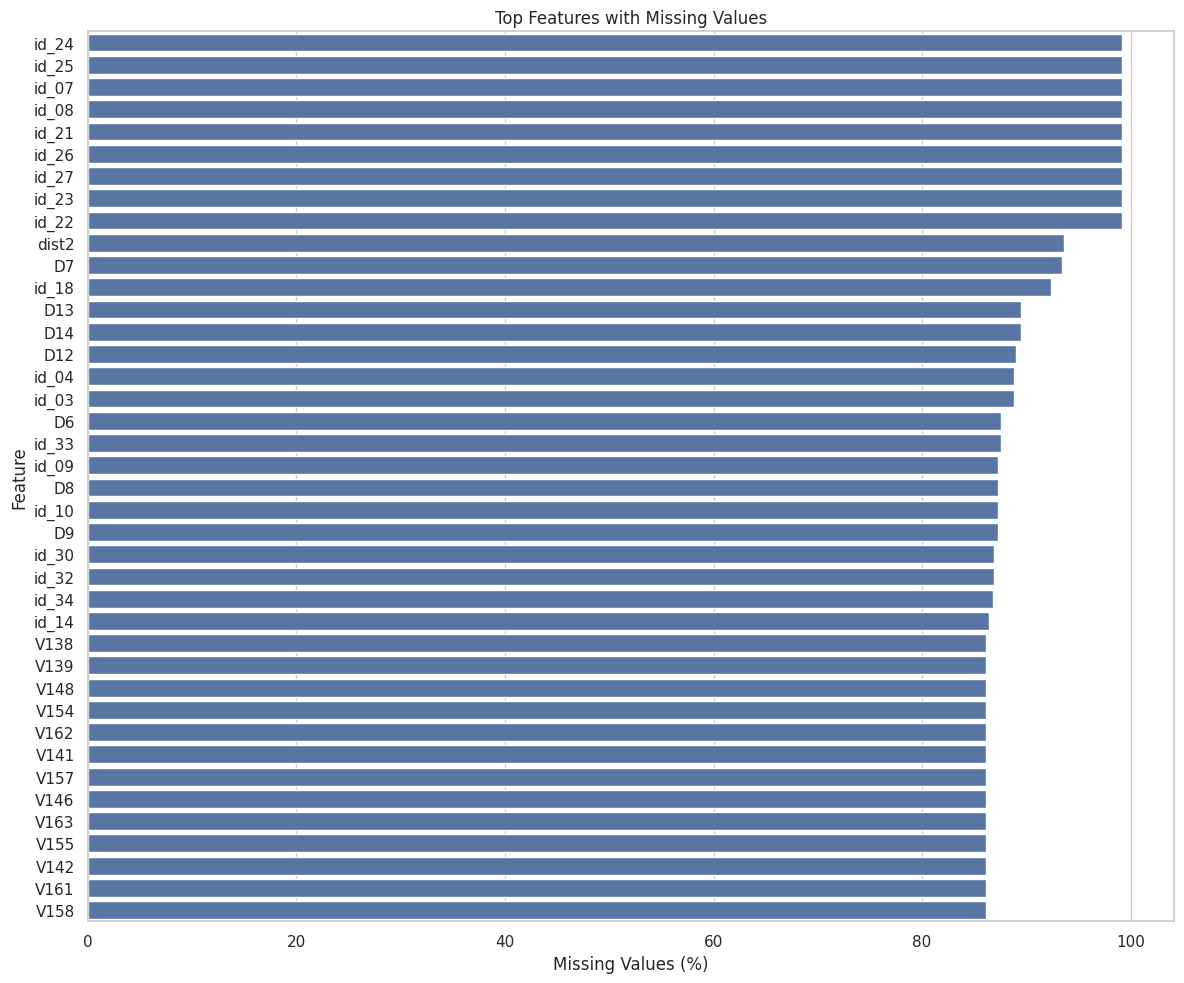

In [ ]:
missing_plot = missing[missing["Missing %"] > 10].head(40)

plt.figure(figsize=(12, 10))
sns.barplot(data=missing_plot.reset_index(), x="Missing %", y="index")
plt.title("Top Features with Missing Values")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 3.3 Missingness Distribution

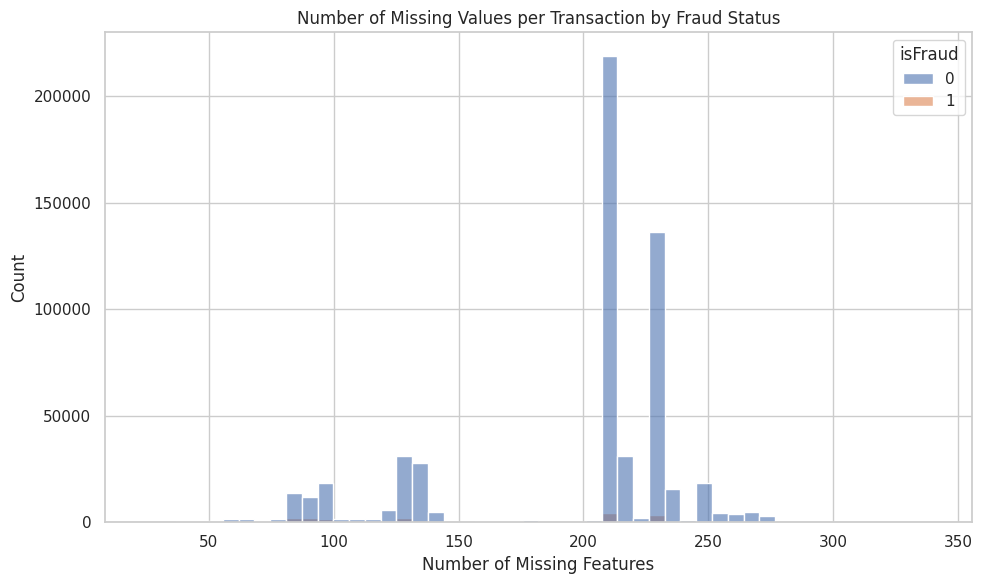

In [ ]:
missing_count_per_row = train.isna().sum(axis=1)

plt.figure(figsize=(10, 6))
sns.histplot(data=train, x=missing_count_per_row, hue="isFraud", bins=50, alpha=0.6)
plt.title("Number of Missing Values per Transaction by Fraud Status")
plt.xlabel("Number of Missing Features")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Part 4: Fraud Target Analysis

### 4.1 Fraud Rate and Class Imbalance

In [ ]:
print("\n" + "="*80)
print("PART 4: FRAUD TARGET ANALYSIS")
print("="*80)

fraud_counts = train["isFraud"].value_counts()
fraud_percent = train["isFraud"].value_counts(normalize=True) * 100

nonfraud = (train["isFraud"] == 0).sum()
fraud = (train["isFraud"] == 1).sum()
imbalance_ratio = nonfraud / fraud

print("Fraud Distribution:")
print(f"Non-Fraud: {nonfraud:,} ({fraud_percent[0]:.4f}%)")
print(f"Fraud: {fraud:,} ({fraud_percent[1]:.4f}%)")
print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}:1")
print("This justifies using Precision, Recall, F1, PR-AUC, and FPR rather than accuracy alone.")


PART 4: FRAUD TARGET ANALYSIS
Fraud Distribution:
Non-Fraud: 569,877 (96.5010%)
Fraud: 20,663 (3.4990%)

Class imbalance ratio: 27.58:1
This justifies using Precision, Recall, F1, PR-AUC, and FPR rather than accuracy alone.


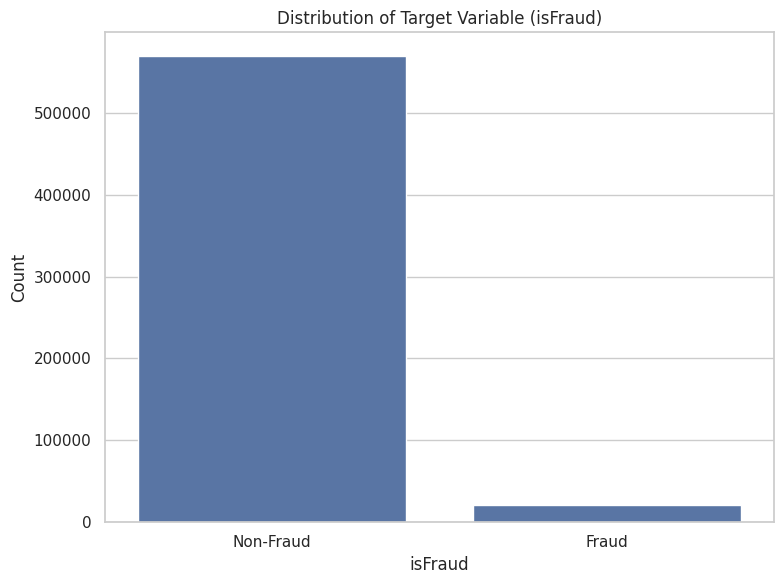

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=train, x="isFraud")
plt.xticks([0, 1], ["Non-Fraud", "Fraud"])
plt.title("Distribution of Target Variable (isFraud)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 4.2 Fraud Value Exposure

In [ ]:
fraud_amount = train[train["isFraud"] == 1]["TransactionAmt"].sum()
total_amount = train["TransactionAmt"].sum()

print(f"Total transaction amount: ${total_amount:,.2f}")
print(f"Fraud transaction amount: ${fraud_amount:,.2f}")
print(f"Fraud amount percentage: {fraud_amount / total_amount * 100:.2f}%")

Total transaction amount: $79,738,948.73
Fraud transaction amount: $3,083,844.86
Fraud amount percentage: 3.87%


## Part 5: Transaction Amount EDA

### 5.1 Amount Distribution by Fraud Status

In [ ]:
print("\n" + "="*80)
print("PART 5: TRANSACTION AMOUNT EDA")
print("="*80)

print("Amount statistics by fraud status:")
display(train.groupby("isFraud")["TransactionAmt"].describe())


PART 5: TRANSACTION AMOUNT EDA
Amount statistics by fraud status:


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


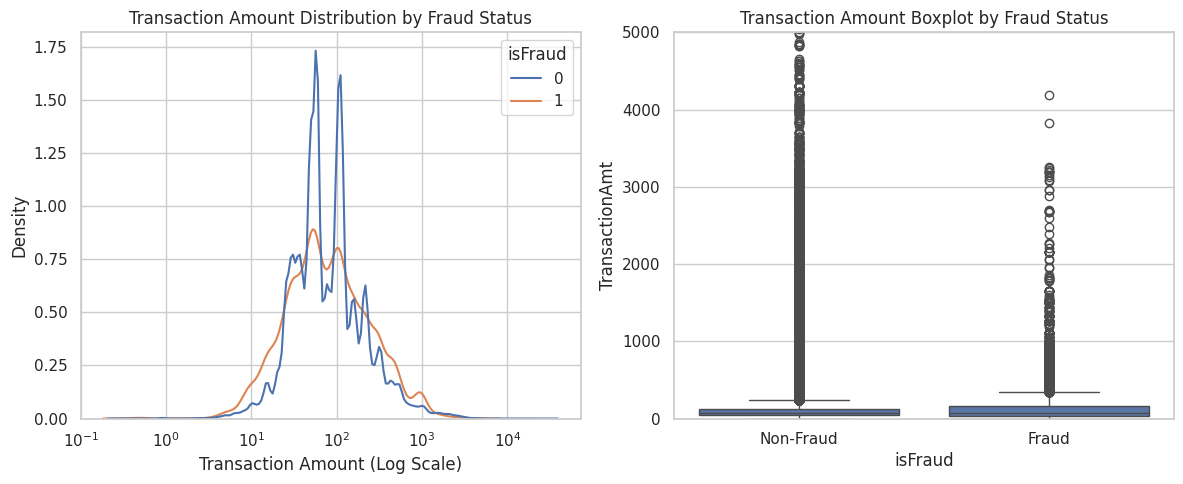

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(data=train, x="TransactionAmt", hue="isFraud", log_scale=True, common_norm=False)
plt.title("Transaction Amount Distribution by Fraud Status")
plt.xlabel("Transaction Amount (Log Scale)")

plt.subplot(1, 2, 2)
sns.boxplot(data=train, x="isFraud", y="TransactionAmt")
plt.ylim(0, 5000)
plt.title("Transaction Amount Boxplot by Fraud Status")
plt.xticks([0, 1], ["Non-Fraud", "Fraud"])

plt.tight_layout()
plt.show()

### 5.2 Amount Quantiles

In [ ]:
print("\nAmount percentiles:")
percentiles = [50, 75, 90, 95, 98, 99, 99.5, 99.9]
for p in percentiles:
    value = train["TransactionAmt"].quantile(p/100)
    print(f"{p}th percentile: ${value:.2f}")


Amount percentiles:
50th percentile: $68.77
75th percentile: $125.00
90th percentile: $275.29
95th percentile: $445.00
98th percentile: $768.95
99th percentile: $1104.00
99.5th percentile: $1656.11
99.9th percentile: $2769.81


### 5.3 Fraud Rate by Amount Group

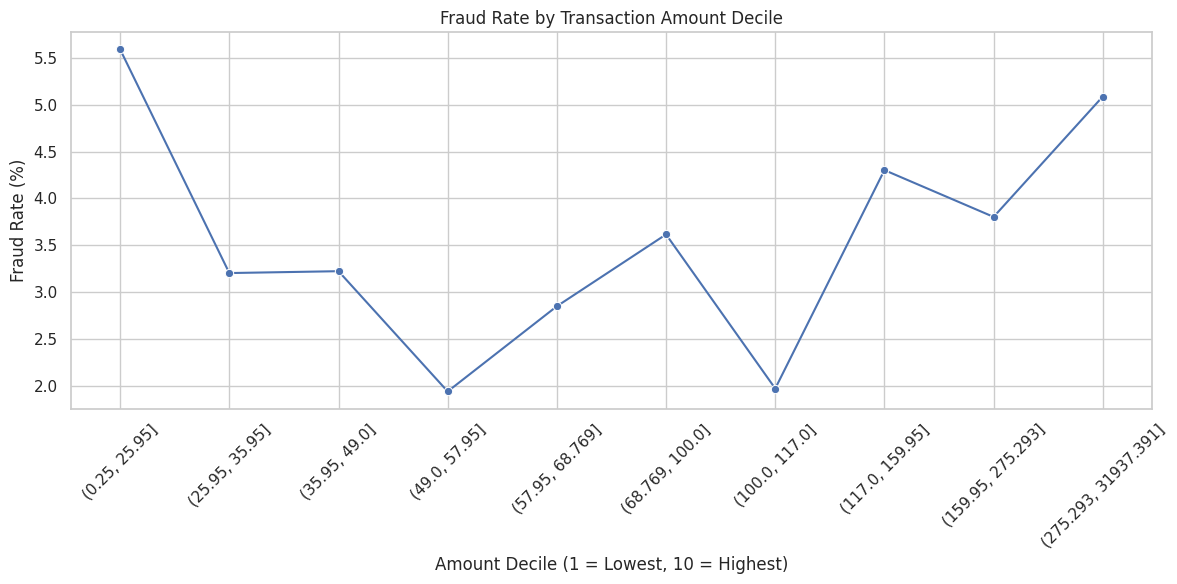

In [ ]:
train["AMOUNT_GROUP"] = pd.qcut(train["TransactionAmt"], q=10, duplicates="drop")

amount_risk = train.groupby("AMOUNT_GROUP", observed=False)["isFraud"].agg(
    Transactions="size",
    Fraud_Rate="mean"
)
amount_risk["Fraud_Rate"] = amount_risk["Fraud_Rate"] * 100

plt.figure(figsize=(12, 6))
sns.lineplot(data=amount_risk.reset_index(), x=amount_risk.index.astype(str), y="Fraud_Rate", marker="o")
plt.title("Fraud Rate by Transaction Amount Decile")
plt.xlabel("Amount Decile (1 = Lowest, 10 = Highest)")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Part 6: Product EDA

### 6.1 Product Distribution

In [ ]:
print("\n" + "="*80)
print("PART 6: PRODUCT EDA")
print("="*80)

print("ProductCD distribution:")
display(train["ProductCD"].value_counts())


PART 6: PRODUCT EDA
ProductCD distribution:


,count
ProductCD,
W,439670
C,68519
R,37699
H,33024
S,11628


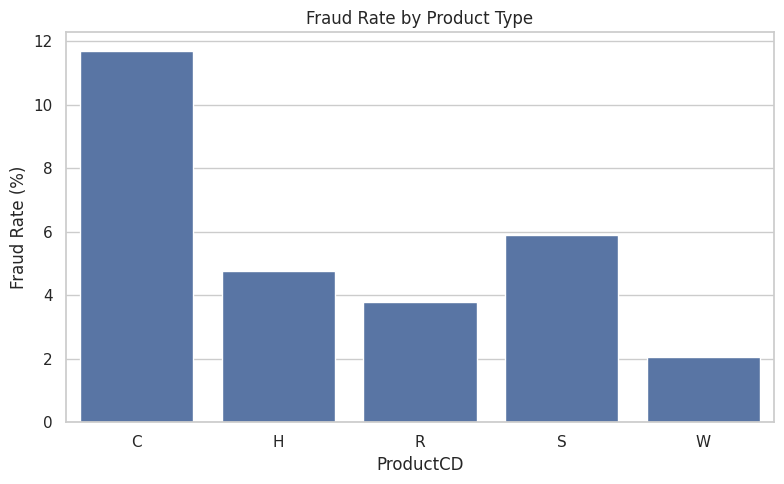

In [ ]:
product_risk = train.groupby("ProductCD")["isFraud"].agg(
    Transactions="size",
    Fraud_Rate="mean"
)
product_risk["Fraud_Rate"] = product_risk["Fraud_Rate"] * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=product_risk.reset_index(), x="ProductCD", y="Fraud_Rate")
plt.title("Fraud Rate by Product Type")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

## Part 7: Card Features EDA

### 7.1 Card Features Overview

In [ ]:
print("\n" + "="*80)
print("PART 7: CARD FEATURES EDA")
print("="*80)

card_cols = [c for c in train.columns if c.startswith("card")]
print("Card columns:", card_cols)

for col in card_cols:
    print(f"\n{col}: {train[col].nunique(dropna=False)} unique values")
    display(train[col].value_counts(dropna=False).head(10))


PART 7: CARD FEATURES EDA
Card columns: ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']

card1: 13553 unique values


,count
card1,
7919,14932
9500,14162
15885,10361
17188,10344
15066,7945
12695,7091
12544,6773
6019,6771
2803,6141



card2: 501 unique values


,count
card2,
321.0,48935
111.0,45191
555.0,41995
490.0,38145
583.0,21803
170.0,18214
194.0,16938
545.0,16355
360.0,15190



card3: 115 unique values


...

,count
card4,
visa,384767
mastercard,189217
american express,8328
discover,6651
NaN,1577



card5: 120 unique values


,count
card5,
226.0,296546
224.0,81513
166.0,57140
102.0,29105
117.0,25941
138.0,19737
195.0,16945
137.0,11720
126.0,10298



card6: 5 unique values


,count
card6,
debit,439938
credit,148986
NaN,1571
debit or credit,30
charge card,15


### 7.2 Generic Categorical Fraud Function

In [ ]:
def fraud_rate_by_category(df, column, min_count=100):
    temp = df.groupby(column, dropna=False)["isFraud"].agg(
        Transactions="size",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
    temp = temp[temp["Transactions"] >= min_count]
    temp["Fraud_Rate"] = temp["Fraud_Rate"] * 100
    return temp.sort_values("Fraud_Rate", ascending=False)

In [ ]:
for col in card_cols:
    result = fraud_rate_by_category(train, col, min_count=100)
    print(f"\nFraud Rate by {col}:")
    display(result.head(15))


Fraud Rate by card1:


,Transactions,Fraud_Count,Fraud_Rate
card1,,,
3643,121,63,52.066116
17999,101,49,48.514851
2939,175,78,44.571429
2801,411,156,37.956204
3702,133,46,34.586466
10369,162,55,33.950617
5009,155,52,33.548387
9917,919,306,33.297062
3867,356,116,32.584270



Fraud Rate by card2:


,Transactions,Fraud_Count,Fraud_Rate
card2,,,
289.0,118,48,40.677966
405.0,228,92,40.350877
319.0,100,39,39.000000
176.0,513,185,36.062378
482.0,168,55,32.738095
311.0,289,81,28.027682
104.0,754,187,24.801061
324.0,331,80,24.169184
177.0,1642,396,24.116931



Fraud Rate by card3:


...

,Transactions,Fraud_Count,Fraud_Rate
card4,,,
discover,6651,514,7.728161
visa,384767,13373,3.475610
mastercard,189217,6496,3.433095
american express,8328,239,2.869837
NaN,1577,41,2.599873



Fraud Rate by card5:


,Transactions,Fraud_Count,Fraud_Rate
card5,,,
137.0,11720,1725,14.718430
147.0,417,47,11.270983
141.0,341,32,9.384164
223.0,936,83,8.867521
138.0,19737,1682,8.522065
144.0,219,16,7.305936
162.0,4524,301,6.653404
203.0,428,28,6.542056
102.0,29105,1832,6.294451



Fraud Rate by card6:


,Transactions,Fraud_Count,Fraud_Rate
card6,,,
credit,148986,9950,6.678480
NaN,1571,39,2.482495
debit,439938,10674,2.426251


## Part 8: Email Domain EDA

### 8.1 Email Domain Analysis

In [ ]:
print("\n" + "="*80)
print("PART 8: EMAIL DOMAIN EDA")
print("="*80)

email_cols = [col for col in ["P_emaildomain", "R_emaildomain"] if col in train.columns]

for col in email_cols:
    print(f"\nFraud Rate by {col}")
    result = fraud_rate_by_category(train, col, min_count=200)
    display(result.head(20))


PART 8: EMAIL DOMAIN EDA

Fraud Rate by P_emaildomain


,Transactions,Fraud_Count,Fraud_Rate
P_emaildomain,,,
mail.com,559,106,18.962433
outlook.es,438,57,13.013699
aim.com,315,40,12.698413
outlook.com,5096,482,9.458399
hotmail.es,305,20,6.557377
live.com.mx,749,41,5.473965
hotmail.com,45250,2396,5.295028
gmail.com,228355,9943,4.354185
embarqmail.com,260,9,3.461538



Fraud Rate by R_emaildomain


,Transactions,Fraud_Count,Fraud_Rate
R_emaildomain,,,
outlook.com,2507,414,16.513761
outlook.es,433,57,13.163972
icloud.com,1398,180,12.875536
gmail.com,57147,6811,11.918386
hotmail.com,27509,2140,7.779272
hotmail.es,292,20,6.849315
live.com.mx,754,44,5.835544
yahoo.com,11842,610,5.151157
live.com,762,38,4.986877


### 8.2 Email Domain Match

In [ ]:
if "P_emaildomain" in train.columns and "R_emaildomain" in train.columns:
    train["EMAIL_DOMAIN_MATCH"] = (train["P_emaildomain"] == train["R_emaildomain"]).astype(int)
    display(train.groupby("EMAIL_DOMAIN_MATCH")["isFraud"].agg(
        Transactions="size",
        Fraud_Rate="mean"
    ))

,Transactions,Fraud_Rate
EMAIL_DOMAIN_MATCH,,
0,488036,0.022070
1,102504,0.096504


## Part 9: Address and Distance Features EDA

### 9.1 Address Features

In [ ]:
print("\n" + "="*80)
print("PART 9: ADDRESS AND DISTANCE FEATURES EDA")
print("="*80)

address_cols = [col for col in ["addr1", "addr2"] if col in train.columns]

for col in address_cols:
    result = fraud_rate_by_category(train, col, min_count=500)
    print(f"\nTop fraud rates for {col}")
    display(result.head(20))


PART 9: ADDRESS AND DISTANCE FEATURES EDA

Top fraud rates for addr1


,Transactions,Fraud_Count,Fraud_Rate
addr1,,,
NaN,65706,7741,11.781268
465.0,503,42,8.349901
122.0,1617,117,7.235622
308.0,1279,83,6.489445
324.0,2173,112,5.154165
203.0,3808,155,4.070378
226.0,4867,189,3.883296
269.0,6404,226,3.529044
512.0,8268,284,3.434930



Top fraud rates for addr2


,Transactions,Fraud_Count,Fraud_Rate
addr2,,,
96.0,638,89,13.949843
NaN,65706,7741,11.781268
60.0,3084,279,9.046693
87.0,520481,12477,2.397206


### 9.2 Distance Features

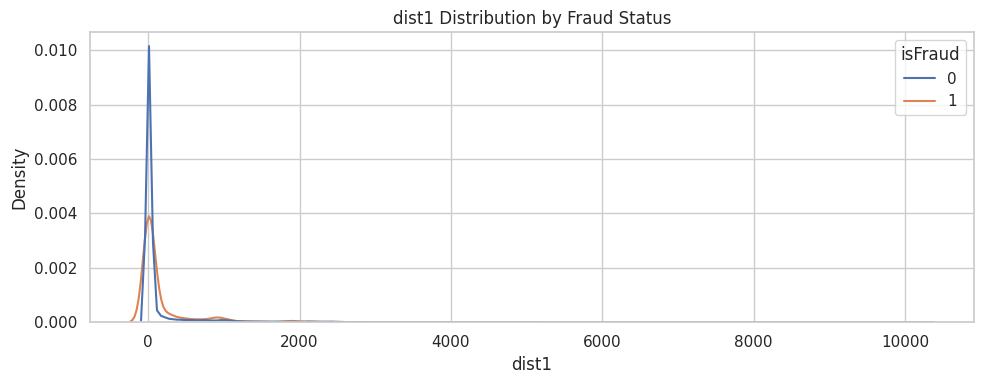

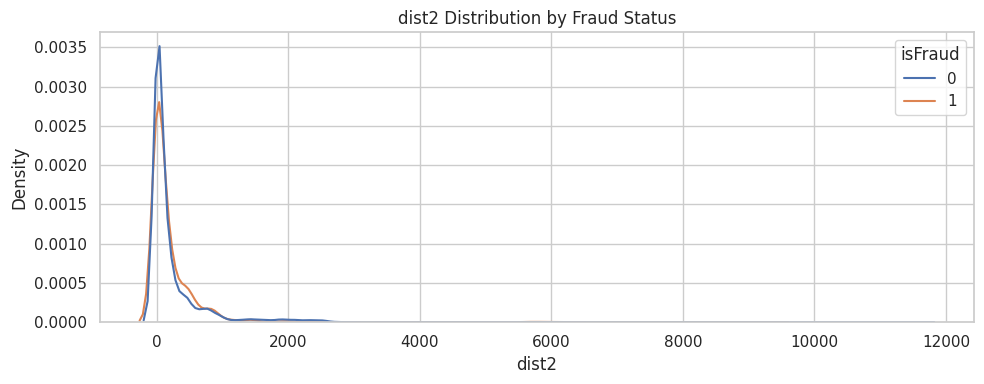

In [ ]:
dist_cols = [c for c in train.columns if c.startswith("dist")]

for col in dist_cols:
    plt.figure(figsize=(10, 4))
    sns.kdeplot(data=train, x=col, hue="isFraud", common_norm=False)
    plt.title(f"{col} Distribution by Fraud Status")
    plt.tight_layout()
    plt.show()

## Part 10: Transaction Time EDA

### 10.1 Time Engineering

In [ ]:
print("\n" + "="*80)
print("PART 10: TRANSACTION TIME EDA")
print("="*80)

train["TRANSACTION_DAY"] = (train["TransactionDT"] // (60 * 60 * 24)).astype(int)
train["TRANSACTION_HOUR"] = ((train["TransactionDT"] // (60 * 60)) % 24).astype(int)
train["TRANSACTION_WEEK"] = (train["TRANSACTION_DAY"] // 7).astype(int)


PART 10: TRANSACTION TIME EDA


### 10.2 Fraud by Hour

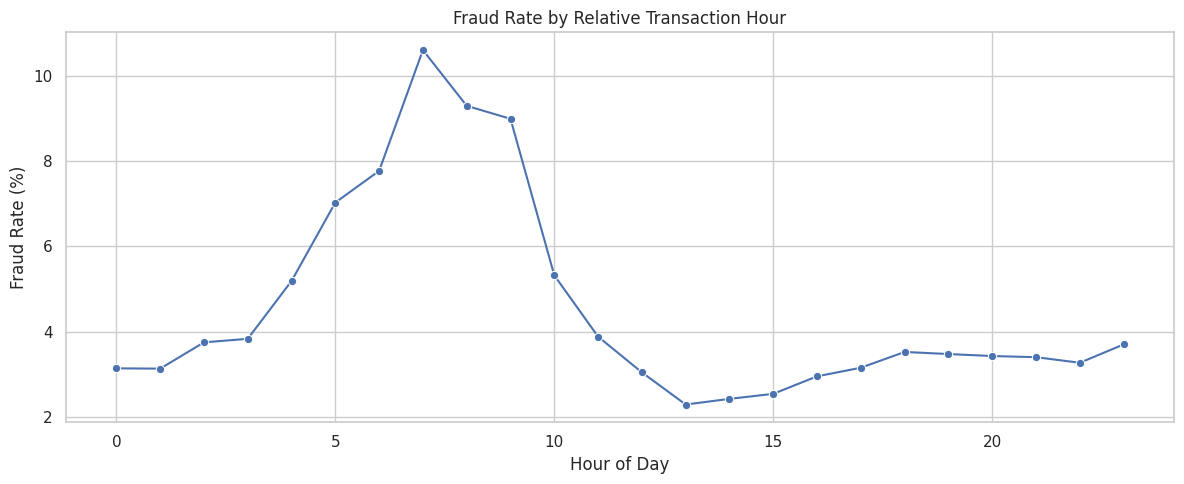

In [ ]:
hourly_fraud = train.groupby("TRANSACTION_HOUR")["isFraud"].agg(
    Transactions="size",
    Fraud_Count="sum",
    Fraud_Rate="mean"
)
hourly_fraud["Fraud_Rate"] = hourly_fraud["Fraud_Rate"] * 100

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_fraud.reset_index(), x="TRANSACTION_HOUR", y="Fraud_Rate", marker="o")
plt.title("Fraud Rate by Relative Transaction Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

### 10.3 Fraud by Day

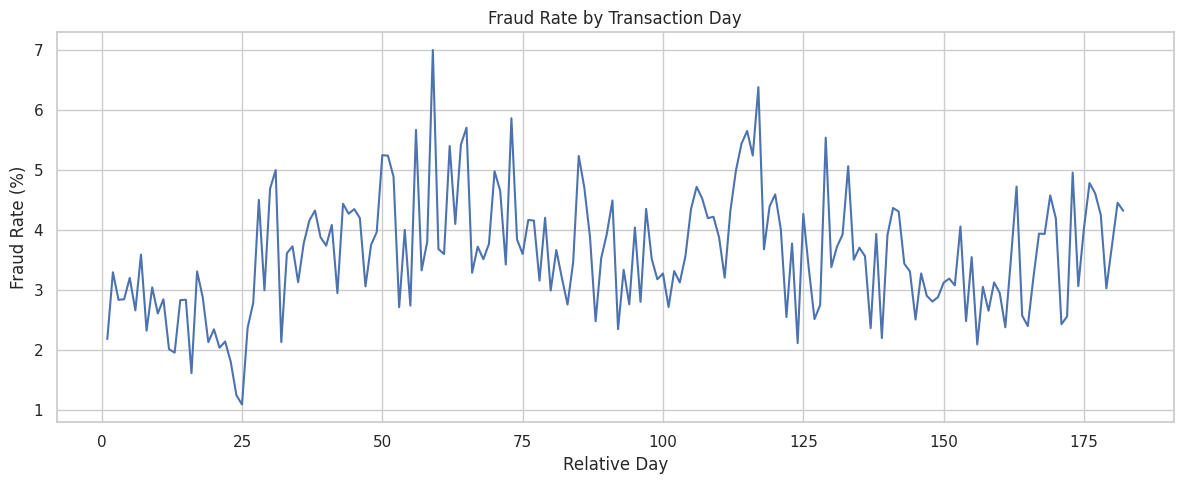

In [ ]:
daily_fraud = train.groupby("TRANSACTION_DAY")["isFraud"].agg(
    Transactions="size",
    Fraud_Rate="mean"
)
daily_fraud["Fraud_Rate"] = daily_fraud["Fraud_Rate"] * 100

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_fraud.reset_index(), x="TRANSACTION_DAY", y="Fraud_Rate")
plt.title("Fraud Rate by Transaction Day")
plt.xlabel("Relative Day")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

## Part 11: Identity EDA

### 11.1 Device Type


PART 11: IDENTITY EDA


,Transactions,Fraud_Count,Fraud_Rate
DeviceType,,,
mobile,55645,5657,10.166232
desktop,85165,5554,6.521458
NaN,449730,9452,2.101705


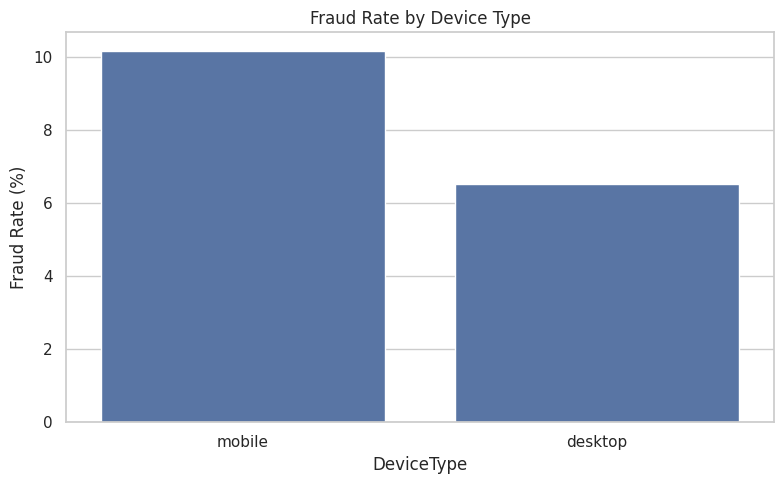

In [ ]:
print("\n" + "="*80)
print("PART 11: IDENTITY EDA")
print("="*80)

if "DeviceType" in train.columns:
    device_type_risk = fraud_rate_by_category(train, "DeviceType", min_count=100)
    display(device_type_risk)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=device_type_risk.reset_index(), x="DeviceType", y="Fraud_Rate")
    plt.ylabel("Fraud Rate (%)")
    plt.title("Fraud Rate by Device Type")
    plt.tight_layout()
    plt.show()

### 11.2 Device Info

In [ ]:
if "DeviceInfo" in train.columns:
    device_info_risk = fraud_rate_by_category(train, "DeviceInfo", min_count=100)
    print("Highest fraud-rate device groups:")
    display(device_info_risk.head(30))

Highest fraud-rate device groups:


,Transactions,Fraud_Count,Fraud_Rate
DeviceInfo,,,
hi6210sft Build/MRA58K,190,180,94.736842
SM-A300H Build/LRX22G,203,169,83.251232
SM-J320M Build/LMY47V,171,57,33.333333
WAS-LX3 Build/HUAWEIWAS-LX3,108,28,25.925926
Moto Z2 Play Build/NPSS26.118-19-14,129,30,23.255814
Moto E (4) Plus Build/NMA26.42-69,160,32,20.000000
SM-J701M Build/NRD90M,154,30,19.480519
SM-G955F Build/NRD90M,134,26,19.402985
Moto E (4) Build/NMA26.42-69,125,23,18.400000


### 11.3 OS and Browser Identity Features

In [ ]:
for col in ["id_30", "id_31", "id_33", "id_34"]:
    if col in train.columns:
        print(f"\n{col}")
        result = fraud_rate_by_category(train, col, min_count=200)
        display(result.head(20))


id_30


,Transactions,Fraud_Count,Fraud_Rate
id_30,,,
Android 5.1.1,350,101,28.857143
iOS 11.1.0,271,48,17.712177
iOS 11.2.5,1200,146,12.166667
iOS 11.2.2,902,106,11.751663
Android 7.1.1,630,67,10.634921
Android,1079,114,10.565338
Windows Vista,246,23,9.349593
iOS 10.2.1,285,25,8.771930
Android 6.0.1,566,48,8.480565



id_31


,Transactions,Fraud_Count,Fraud_Rate
id_31,,,
android webview 4.0,285,69,24.210526
firefox,673,147,21.842496
other,312,61,19.551282
chrome 58.0 for android,262,50,19.083969
chrome 56.0 for android,238,44,18.487395
chrome generic,4778,803,16.806195
chrome 64.0 for android,3473,552,15.894040
chrome 65.0 for android,3336,491,14.718225
samsung browser generic,210,29,13.809524



id_33


,Transactions,Fraud_Count,Fraud_Rate
id_33,,,
855x480,250,95,38.000000
1280x720,1318,181,13.732929
2436x1125,1484,168,11.320755
2208x1242,4900,482,9.836735
2001x1125,1020,61,5.980392
1334x750,6447,381,5.909725
1366x768,8605,493,5.729227
2220x1080,544,29,5.330882
1360x768,224,11,4.910714



id_34


,Transactions,Fraud_Count,Fraud_Rate
id_34,,,
match_status:1,17376,1106,6.365101
match_status:0,415,21,5.060241
match_status:2,60011,2358,3.929280
NaN,512735,17178,3.350269


## Part 12: Engineered Features EDA

### 12.1 C Features (Count Features)

In [ ]:
print("\n" + "="*80)
print("PART 12: ENGINEERED FEATURES EDA")
print("="*80)

c_cols = [c for c in train.columns if c.startswith("C") and c[1:].isdigit()]
print("C features:", c_cols)

c_summary = train.groupby("isFraud")[c_cols].median().T
display(c_summary)


PART 12: ENGINEERED FEATURES EDA
C features: ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']


isFraud,0,1
C1,1.0,2.0
C2,1.0,2.0
C3,0.0,0.0
C4,0.0,1.0
C5,0.0,0.0
C6,1.0,1.0
C7,0.0,0.0
C8,0.0,1.0
C9,1.0,0.0
C10,0.0,1.0


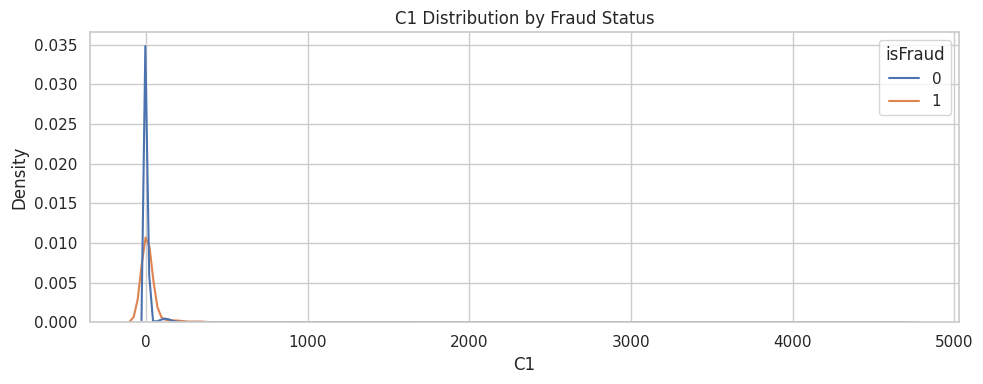

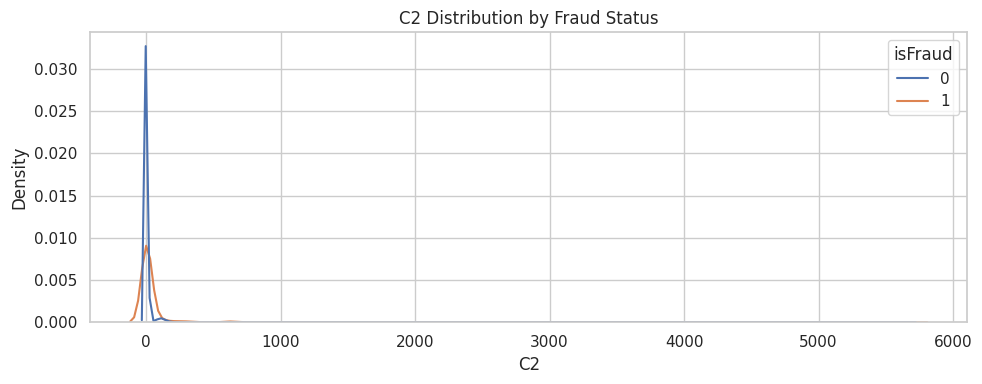

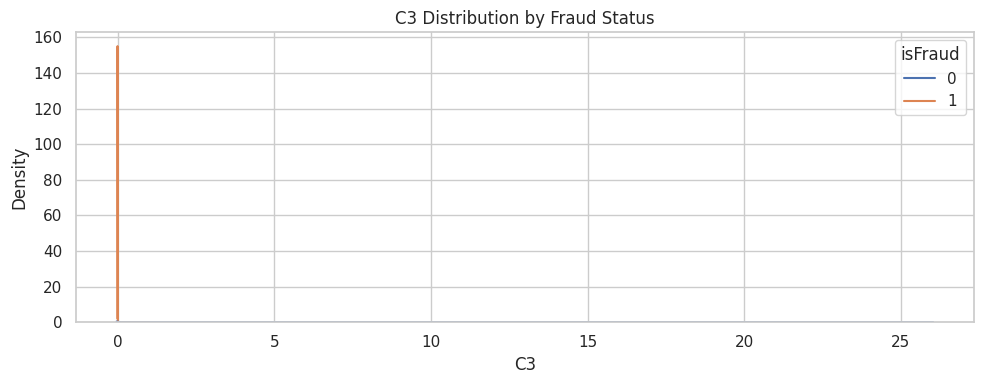

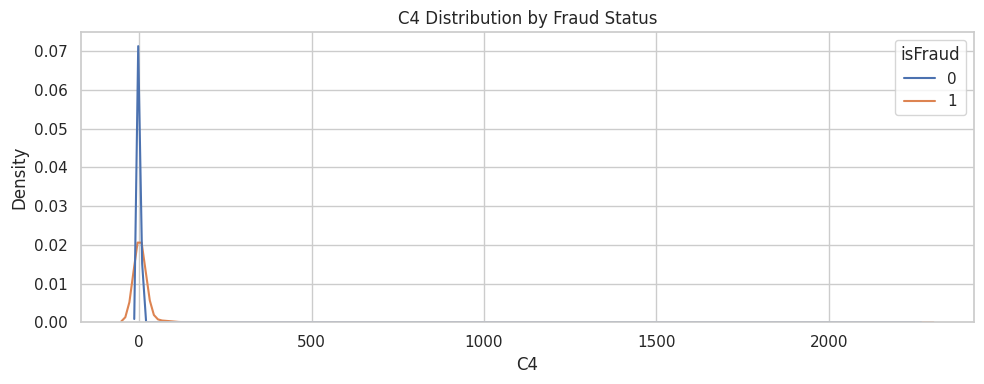

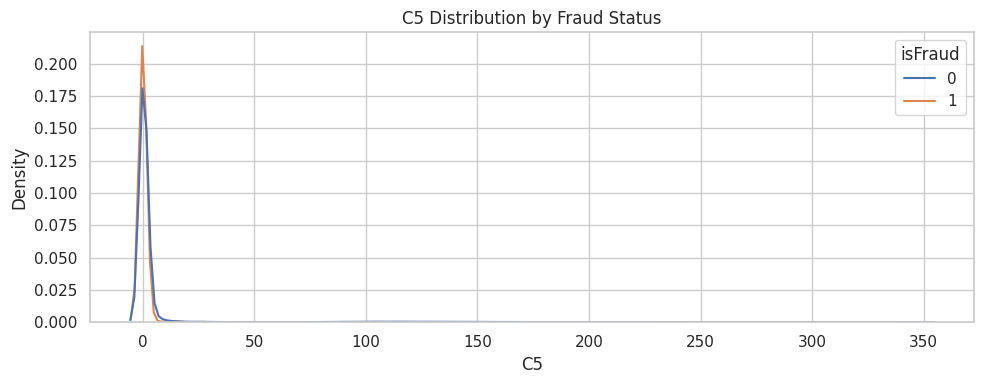

In [ ]:
for col in c_cols[:5]:
    plt.figure(figsize=(10, 4))
    sns.kdeplot(data=train, x=col, hue="isFraud", common_norm=False)
    plt.title(f"{col} Distribution by Fraud Status")
    plt.tight_layout()
    plt.show()

### 12.2 D Features (Time Difference Features)

In [ ]:
d_cols = [c for c in train.columns if c.startswith("D") and c[1:].isdigit()]
print("D features:", d_cols)

d_summary = train.groupby("isFraud")[d_cols].median().T
display(d_summary)

D features: ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15']


isFraud,0,1
D1,4.000000,0.000000
D2,100.000000,16.000000
D3,8.000000,1.000000
D4,28.000000,1.000000
D5,10.000000,0.000000
D6,0.000000,0.000000
D7,0.000000,0.000000
D8,50.583332,2.666666
D9,0.666666,0.625000
D10,18.000000,0.000000


### 12.3 M Features (Match Features)

In [ ]:
m_cols = [c for c in train.columns if c.startswith("M") and c[1:].isdigit()]
print("M features:", m_cols)

for col in m_cols[:5]:
    print(f"\n{col}")
    result = fraud_rate_by_category(train, col, min_count=100)
    display(result.head(10))

M features: ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']

M1


,Transactions,Fraud_Count,Fraud_Rate
M1,,,
NaN,271100,14321,5.282553
T,319415,6342,1.985505



M2


,Transactions,Fraud_Count,Fraud_Rate
M2,,,
NaN,271100,14321,5.282553
F,33972,1184,3.485223
T,285468,5158,1.806858



M3


,Transactions,Fraud_Count,Fraud_Rate
M3,,,
NaN,271100,14321,5.282553
F,67709,2049,3.026186
T,251731,4293,1.705392



M4


,Transactions,Fraud_Count,Fraud_Rate
M4,,,
M2,59865,6809,11.373925
M0,196405,7198,3.664876
M1,52826,1429,2.705107
NaN,281444,5227,1.857208



M5


,Transactions,Fraud_Count,Fraud_Rate
M5,,,
T,107567,4055,3.769744
NaN,350482,13094,3.735998
F,132491,3514,2.652256


### 12.4 V Features (Vesta Engineered Features)

In [ ]:
v_cols = [c for c in train.columns if c.startswith("V") and c[1:].isdigit()]
print(f"Number of V features: {len(v_cols)}")

Number of V features: 339


In [ ]:
v_missing = pd.DataFrame({
    "Feature": v_cols,
    "Missing %": [train[col].isna().mean() * 100 for col in v_cols]
})
v_missing = v_missing.sort_values("Missing %", ascending=False)
display(v_missing.head(30))

,Feature,Missing %
152,V153,86.123717
145,V146,86.123717
141,V142,86.123717
140,V141,86.123717
162,V163,86.123717
147,V148,86.123717
148,V149,86.123717
154,V155,86.123717
153,V154,86.123717
156,V157,86.123717


## CHECKPOINT: Clear Memory Before Part 13

In [ ]:
# ============================================================
# CHECKPOINT: Clear Memory Before Part 13
# ============================================================

print("Clearing memory before Part 13...")

# Delete all large dataframes
try:
    del train, test, train_transaction, train_identity, test_transaction, test_identity, sample_submission, datasets
except:
    pass

gc.collect()

# Reset all variables (keeps outputs visible!)
%reset -f

# Re-import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score
import gc
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

# Re-define paths
BASE_PATH = Path("/content/drive/MyDrive/FYP/Dataset/IEEE-CIS FRAUD DETECTION")
TRAIN_PATH = BASE_PATH / "train_transaction.csv"

print("\nMemory cleared successfully!")
print("All previous outputs (graphs, tables, prints) are still visible.")
print("Ready for Part 13.")

Clearing memory before Part 13...

Memory cleared successfully!
All previous outputs (graphs, tables, prints) are still visible.
Ready for Part 13.


## Part 13: Feature Association Analysis - Low RAM Version

In [ ]:
# Read column names only - almost no RAM used
all_columns = pd.read_csv(TRAIN_PATH, nrows=0).columns.tolist()

print("Total transaction columns:", len(all_columns))

Total transaction columns: 394


In [ ]:
# Vesta engineered features
v_cols = [c for c in all_columns if c.startswith("V") and c[1:].isdigit()]

# Count features
c_cols = [c for c in all_columns if c.startswith("C") and c[1:].isdigit()]

# Time-difference features
d_cols = [c for c in all_columns if c.startswith("D") and c[1:].isdigit()]

# Important numeric transaction features
key_numeric = ["TransactionAmt", "TransactionDT", "card1", "card2", "card3", "card5", "addr1", "addr2", "dist1", "dist2"]
key_numeric = [c for c in key_numeric if c in all_columns]

candidate_features = key_numeric + c_cols + d_cols + v_cols

# Remove accidental duplicates
candidate_features = list(dict.fromkeys(candidate_features))

print("V features:", len(v_cols))
print("C features:", len(c_cols))
print("D features:", len(d_cols))
print("Other numeric features:", len(key_numeric))
print("Total candidate features:", len(candidate_features))

V features: 339
C features: 14
D features: 15
Other numeric features: 10
Total candidate features: 378


In [ ]:
# Create representative 10% sample using chunks

usecols = ["isFraud"] + candidate_features

# Store numeric data as float32 immediately
dtype_map = {col: "float32" for col in candidate_features}
dtype_map["isFraud"] = "uint8"

sample_parts = []

CHUNK_SIZE = 50000
SAMPLE_FRACTION = 0.10

print("Creating representative 10% sample...")

for chunk_number, chunk in enumerate(pd.read_csv(TRAIN_PATH, usecols=usecols, dtype=dtype_map, chunksize=CHUNK_SIZE)):
    sampled_chunk = chunk.sample(frac=SAMPLE_FRACTION, random_state=42 + chunk_number)
    sample_parts.append(sampled_chunk)
    del chunk
    del sampled_chunk
    gc.collect()
    print(f"Processed chunk {chunk_number + 1}")

assoc_df = pd.concat(sample_parts, ignore_index=True)
del sample_parts
gc.collect()

print("\nFeature association sample created!")
print("Shape:", assoc_df.shape)
print("RAM used by sample:", round(assoc_df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")
print("\nFraud rate in sample:", round(assoc_df["isFraud"].mean() * 100, 4), "%")

Creating representative 10% sample...
Processed chunk 1
Processed chunk 2
Processed chunk 3
Processed chunk 4
Processed chunk 5
Processed chunk 6
Processed chunk 7
Processed chunk 8
Processed chunk 9
Processed chunk 10
Processed chunk 11
Processed chunk 12

Feature association sample created!
Shape: (59054, 379)
RAM used by sample: 85.21 MB

Fraud rate in sample: 3.6289 %


In [ ]:
# Check fraud distribution in sample
fraud_sample_summary = assoc_df["isFraud"].value_counts().rename_axis("isFraud").reset_index(name="Count")
fraud_sample_summary["Percentage"] = fraud_sample_summary["Count"] / len(assoc_df) * 100
display(fraud_sample_summary)

,isFraud,Count,Percentage
0,0,56911,96.371118
1,1,2143,3.628882


In [ ]:
# 13.1 Correlation with Fraud

print("\n" + "="*80)
print("13.1 CORRELATION WITH FRAUD")
print("="*80)

correlation_results = []
target = assoc_df["isFraud"].astype("float32")

for i, col in enumerate(candidate_features):
    try:
        corr = assoc_df[col].corr(target)
        if pd.notna(corr):
            correlation_results.append({
                "Feature": col,
                "Correlation": corr,
                "Absolute_Correlation": abs(corr)
            })
    except Exception:
        continue

    if (i + 1) % 50 == 0:
        print(f"Processed {i + 1}/{len(candidate_features)}")
        gc.collect()

correlation_df = pd.DataFrame(correlation_results).sort_values("Absolute_Correlation", ascending=False)

print("\nTop 30 numeric features associated with fraud:")
display(correlation_df.head(30))


13.1 CORRELATION WITH FRAUD
Processed 50/378
Processed 100/378
Processed 150/378
Processed 200/378
Processed 250/378
Processed 300/378
Processed 350/378

Top 30 numeric features associated with fraud:


,Feature,Correlation,Absolute_Correlation
295,V257,0.385123,0.385123
284,V246,0.369170,0.369170
282,V244,0.349065,0.349065
280,V242,0.348964,0.348964
239,V201,0.337980,0.337980
238,V200,0.327400,0.327400
227,V189,0.317035,0.317035
226,V188,0.305709,0.305709
83,V45,0.293172,0.293172
296,V258,0.281730,0.281730


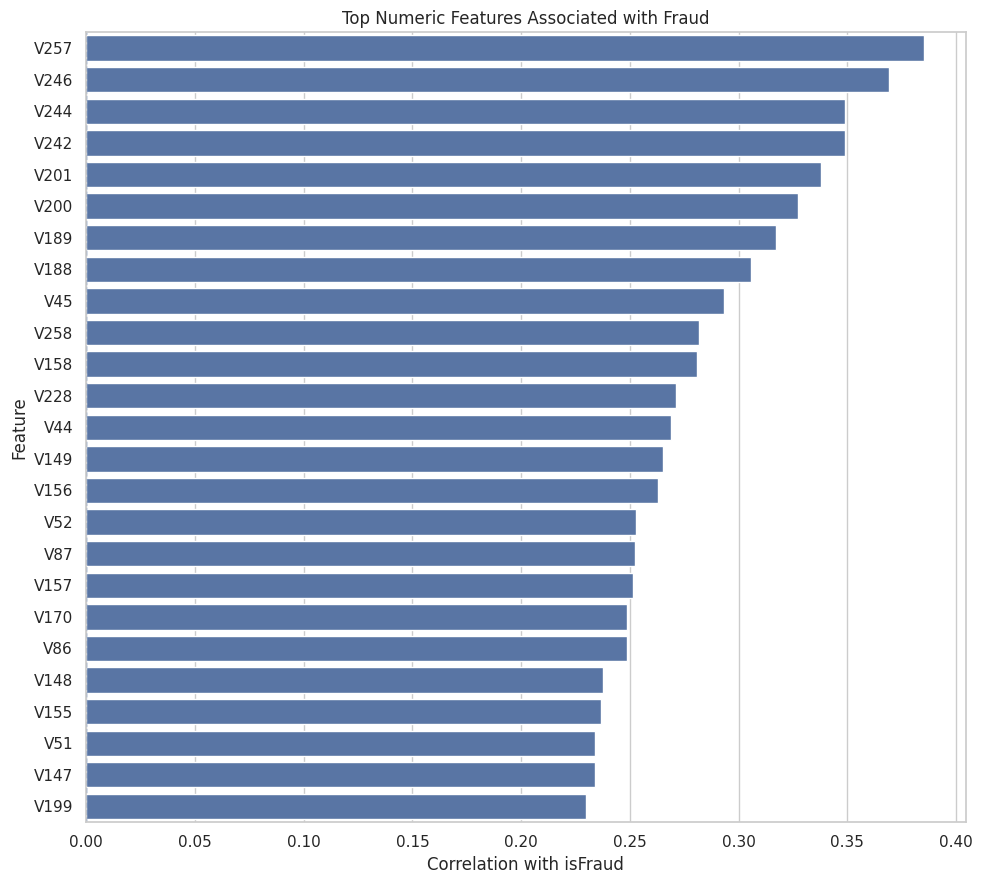

In [ ]:
# Plot strongest correlations
top_corr = correlation_df.head(25)

plt.figure(figsize=(10, 9))
sns.barplot(data=top_corr, x="Correlation", y="Feature")
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Top Numeric Features Associated with Fraud")
plt.xlabel("Correlation with isFraud")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# 13.2 Univariate AUC Feature Ranking

print("\n" + "="*80)
print("13.2 UNIVARIATE AUC FEATURE RANKING")
print("="*80)

auc_results = []
target_array = assoc_df["isFraud"].to_numpy()

for i, col in enumerate(candidate_features):
    try:
        x = assoc_df[col].to_numpy(copy=False)
        valid = np.isfinite(x)

        if valid.sum() < 500:
            continue

        x_valid = x[valid]
        y_valid = target_array[valid]

        if np.unique(x_valid).size < 2:
            continue

        if np.unique(y_valid).size < 2:
            continue

        auc = roc_auc_score(y_valid, x_valid)
        predictive_auc = max(auc, 1 - auc)

        auc_results.append({
            "Feature": col,
            "Raw_AUC": auc,
            "Predictive_AUC": predictive_auc,
            "Available_Rows": valid.sum()
        })

        del x
        del valid
        del x_valid
        del y_valid

    except Exception:
        continue

    if (i + 1) % 50 == 0:
        print(f"Processed {i + 1}/{len(candidate_features)}")
        gc.collect()

auc_df = pd.DataFrame(auc_results).sort_values("Predictive_AUC", ascending=False)

print("\nTop 30 features by Univariate AUC:")
display(auc_df.head(30))


13.2 UNIVARIATE AUC FEATURE RANKING
Processed 50/378
Processed 100/378
Processed 150/378
Processed 200/378
Processed 250/378
Processed 300/378
Processed 350/378

Top 30 features by Univariate AUC:


,Feature,Raw_AUC,Predictive_AUC,Available_Rows
296,V258,0.748463,0.748463,12981
28,D5,0.254653,0.745347,28144
256,V218,0.740039,0.740039,12981
302,V264,0.733941,0.733941,12981
257,V219,0.733273,0.733273,12981
303,V265,0.726466,0.726466,12981
295,V257,0.724890,0.724890,12981
270,V232,0.712469,0.712469,12981
312,V274,0.711624,0.711624,12981
267,V229,0.711242,0.711242,12981


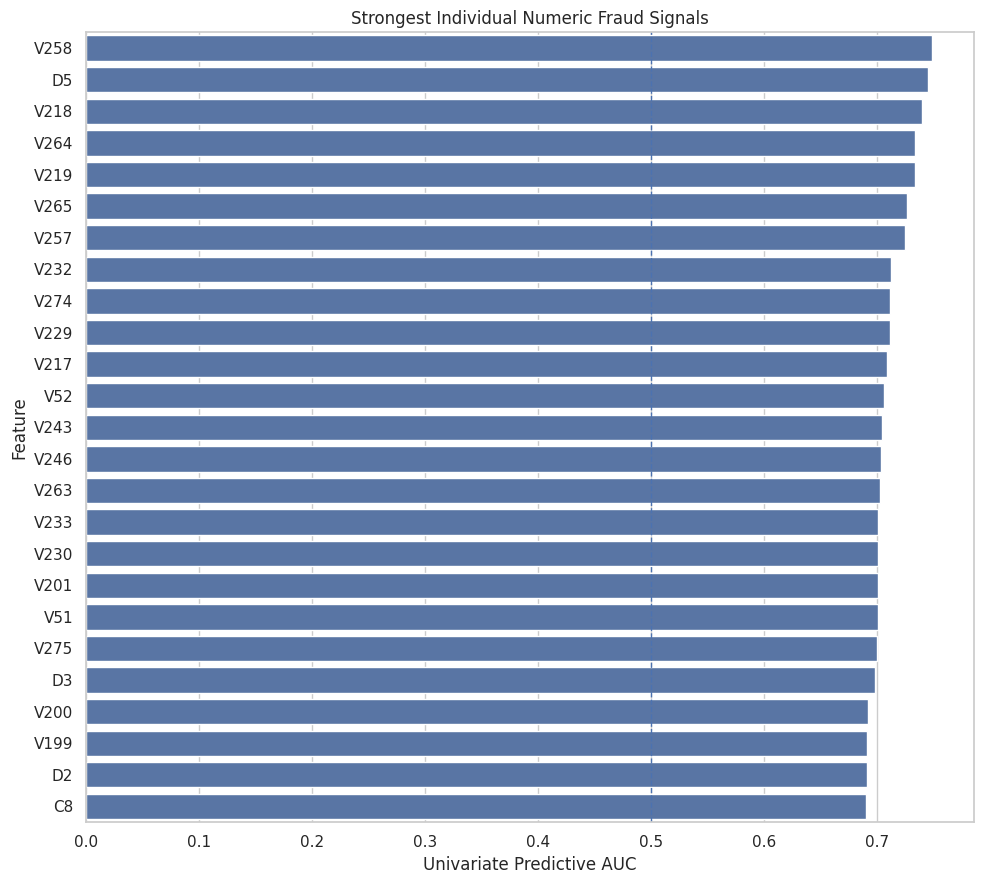

In [ ]:
# Plot Univariate AUC
top_auc = auc_df.head(25)

plt.figure(figsize=(10, 9))
sns.barplot(data=top_auc, x="Predictive_AUC", y="Feature")
plt.axvline(0.5, linestyle="--", linewidth=1)
plt.xlabel("Univariate Predictive AUC")
plt.ylabel("Feature")
plt.title("Strongest Individual Numeric Fraud Signals")
plt.tight_layout()
plt.show()

In [ ]:
# 13.3 Missingness as Fraud Signal

print("\n" + "="*80)
print("13.3 MISSINGNESS AS FRAUD SIGNAL")
print("="*80)

missing_results = []
target_array = assoc_df["isFraud"].to_numpy()

for i, col in enumerate(candidate_features):
    missing_count = assoc_df[col].isna().sum()

    if missing_count == 0:
        continue

    missing_flag = assoc_df[col].isna().to_numpy(dtype=np.uint8)

    if missing_flag.min() == missing_flag.max():
        del missing_flag
        continue

    try:
        auc = roc_auc_score(target_array, missing_flag)
        missing_results.append({
            "Feature": col,
            "Missing_Percentage": missing_count / len(assoc_df) * 100,
            "Predictive_AUC": max(auc, 1 - auc)
        })
    except Exception:
        pass

    del missing_flag

    if (i + 1) % 50 == 0:
        gc.collect()

missing_fraud_df = pd.DataFrame(missing_results).sort_values("Predictive_AUC", ascending=False)

print("\nTop missingness-related fraud signals:")
display(missing_fraud_df.head(30))


13.3 MISSINGNESS AS FRAUD SIGNAL

Top missingness-related fraud signals:


,Feature,Missing_Percentage,Predictive_AUC
190,V169,76.380939,0.657814
216,V195,76.380939,0.657814
218,V197,76.380939,0.657814
222,V201,76.380939,0.657814
219,V198,76.380939,0.657814
221,V200,76.380939,0.657814
215,V194,76.380939,0.657814
201,V180,76.380939,0.657814
196,V175,76.380939,0.657814
195,V174,76.380939,0.657814


In [ ]:
# Final combined feature-association table
feature_association_summary = correlation_df[["Feature", "Correlation", "Absolute_Correlation"]].merge(
    auc_df[["Feature", "Predictive_AUC"]], on="Feature", how="outer"
)
feature_association_summary = feature_association_summary.sort_values("Predictive_AUC", ascending=False)

print("Final Feature Association Summary")
display(feature_association_summary.head(30))

Final Feature Association Summary


,Feature,Correlation,Absolute_Correlation,Predictive_AUC
207,V258,0.281730,0.281730,0.748463
24,D5,-0.069431,0.069431,0.745347
163,V218,0.049581,0.049581,0.740039
214,V264,0.007533,0.007533,0.733941
164,V219,0.051217,0.051217,0.733273
215,V265,0.017812,0.017812,0.726466
206,V257,0.385123,0.385123,0.724890
179,V232,0.058137,0.058137,0.712469
225,V274,0.013852,0.013852,0.711624
175,V229,0.113842,0.113842,0.711242


In [ ]:
# Save the results
correlation_df.to_csv(BASE_PATH / "fraud_feature_correlations.csv", index=False)
auc_df.to_csv(BASE_PATH / "fraud_univariate_auc.csv", index=False)
missing_fraud_df.to_csv(BASE_PATH / "fraud_missingness_association.csv", index=False)
feature_association_summary.to_csv(BASE_PATH / "fraud_feature_association_summary.csv", index=False)

print("All feature association results saved to Google Drive!")

All feature association results saved to Google Drive!


In [ ]:
# Delete the sample
del assoc_df
gc.collect()

print("Feature association sample removed from RAM.")

Feature association sample removed from RAM.


## Part 14: Static Rule Baseline - Low RAM

In [ ]:
print("\n" + "="*80)
print("PART 14: STATIC RULE BASELINE - LOW RAM")
print("="*80)

rule_df = pd.read_csv(TRAIN_PATH, usecols=["TransactionAmt", "isFraud"], dtype={"TransactionAmt": "float32", "isFraud": "uint8"})

print("Static rule dataset:", rule_df.shape)


PART 14: STATIC RULE BASELINE - LOW RAM
Static rule dataset: (590540, 2)


In [ ]:
amount_95 = rule_df["TransactionAmt"].quantile(0.95)
print(f"95th percentile amount: ${amount_95:.2f}")

rule_df["STATIC_AMOUNT_FLAG"] = (rule_df["TransactionAmt"] >= amount_95).astype("uint8")

tp = ((rule_df["STATIC_AMOUNT_FLAG"] == 1) & (rule_df["isFraud"] == 1)).sum()
fp = ((rule_df["STATIC_AMOUNT_FLAG"] == 1) & (rule_df["isFraud"] == 0)).sum()
tn = ((rule_df["STATIC_AMOUNT_FLAG"] == 0) & (rule_df["isFraud"] == 0)).sum()
fn = ((rule_df["STATIC_AMOUNT_FLAG"] == 0) & (rule_df["isFraud"] == 1)).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

print("\n95th Percentile Static Rule Performance")
print(f"True Positives: {tp:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"False Positive Rate: {fpr:.4f}")

95th percentile amount: $445.00

95th Percentile Static Rule Performance
True Positives: 1,590
False Positives: 27,970
False Negatives: 19,073
Precision: 0.0538
Recall: 0.0769
False Positive Rate: 0.0491


In [ ]:
# Evaluate multiple thresholds
rule_results = []

for percentile in [90, 95, 98, 99, 99.5, 99.9]:
    threshold = rule_df["TransactionAmt"].quantile(percentile/100)
    predicted = (rule_df["TransactionAmt"] >= threshold).astype(int)
    actual = rule_df["isFraud"]

    tp = ((predicted == 1) & (actual == 1)).sum()
    fp = ((predicted == 1) & (actual == 0)).sum()
    tn = ((predicted == 0) & (actual == 0)).sum()
    fn = ((predicted == 0) & (actual == 1)).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    rule_results.append({
        "Percentile": percentile,
        "Amount Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "False Positive Rate": fpr,
        "False Positives": fp,
        "Frauds Detected": tp
    })

rule_results_df = pd.DataFrame(rule_results)
display(rule_results_df)

# Save static rule results
rule_results_df.to_csv(BASE_PATH / "static_rule_results.csv", index=False)

,Percentile,Amount Threshold,Precision,Recall,False Positive Rate,False Positives,Frauds Detected
0,90.0,275.292999,0.050966,0.145671,0.098353,56049,3010
1,95.0,445.000000,0.053789,0.076949,0.049081,27970,1590
2,98.0,768.950012,0.051380,0.029376,0.019666,11207,607
3,99.0,1104.000000,0.026556,0.008034,0.010678,6085,166
4,99.5,1656.109985,0.017603,0.002517,0.005092,2902,52
5,99.9,2769.807340,0.028765,0.000823,0.001007,574,17


## Part 15: Interaction EDA


PART 15: INTERACTION EDA


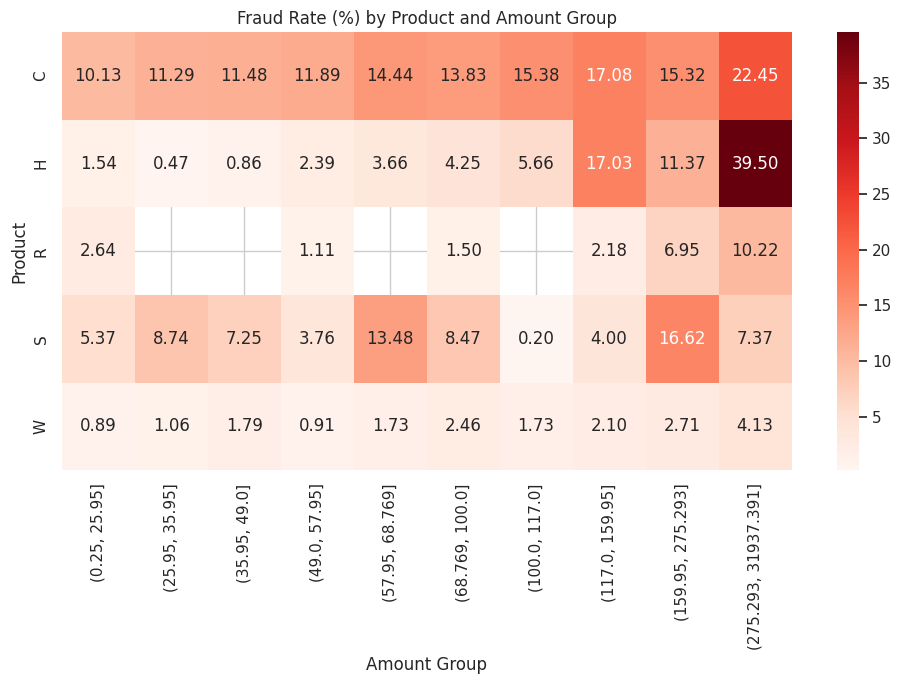

7947

In [ ]:
# Load only what we need for interaction
interaction_data = pd.read_csv(TRAIN_PATH, usecols=["TransactionAmt", "ProductCD", "isFraud"], dtype={"TransactionAmt": "float32", "isFraud": "uint8"})

interaction_data["AMOUNT_GROUP"] = pd.qcut(interaction_data["TransactionAmt"], q=10, duplicates="drop")

print("\n" + "="*80)
print("PART 15: INTERACTION EDA")
print("="*80)

interaction_product_amount = interaction_data.groupby(["ProductCD", "AMOUNT_GROUP"], observed=False)["isFraud"].mean().unstack()

plt.figure(figsize=(10, 7))
sns.heatmap(interaction_product_amount * 100, annot=True, fmt=".2f", cmap="Reds")
plt.title("Fraud Rate (%) by Product and Amount Group")
plt.xlabel("Amount Group")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

del interaction_data
gc.collect()

## Part 16: Summary

In [ ]:
print("\n" + "="*80)
print("PART 16: SUMMARY")
print("="*80)

print("\nTop 10 features by correlation:")
display(correlation_df.head(10))

print("\nTop 10 features by AUC:")
display(auc_df.head(10))


PART 16: SUMMARY

Top 10 features by correlation:


,Feature,Correlation,Absolute_Correlation
295,V257,0.385123,0.385123
284,V246,0.369170,0.369170
282,V244,0.349065,0.349065
280,V242,0.348964,0.348964
239,V201,0.337980,0.337980
238,V200,0.327400,0.327400
227,V189,0.317035,0.317035
226,V188,0.305709,0.305709
83,V45,0.293172,0.293172
296,V258,0.281730,0.281730



Top 10 features by AUC:


,Feature,Raw_AUC,Predictive_AUC,Available_Rows
296,V258,0.748463,0.748463,12981
28,D5,0.254653,0.745347,28144
256,V218,0.740039,0.740039,12981
302,V264,0.733941,0.733941,12981
257,V219,0.733273,0.733273,12981
303,V265,0.726466,0.726466,12981
295,V257,0.724890,0.724890,12981
270,V232,0.712469,0.712469,12981
312,V274,0.711624,0.711624,12981
267,V229,0.711242,0.711242,12981


In [ ]:
print("\n" + "="*80)
print("EDA Complete!")
print("="*60)

print("\nResults saved to Google Drive:")
print("  - fraud_feature_correlations.csv")
print("  - fraud_univariate_auc.csv")
print("  - fraud_missingness_association.csv")
print("  - fraud_feature_association_summary.csv")
print("  - static_rule_results.csv")


EDA Complete!

Results saved to Google Drive:
  - fraud_feature_correlations.csv
  - fraud_univariate_auc.csv
  - fraud_missingness_association.csv
  - fraud_feature_association_summary.csv
  - static_rule_results.csv
